# Testing rbf with wasserstein loss

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import numpy as np
import logging
import sys
from pathlib import Path
import torch
from IPython.display import display

import matplotlib.pyplot as plt
import diffmeshopt.opt2d.hyperparameter_search as hps
from diffmeshopt.opt2d.hyperparameter_search import ExperimentRunner
import diffmeshopt.opt2d.evaluation as evaluation
from diffmeshopt.opt2d import vis
from pprint import pprint
import diffmeshopt.opt2d.debug as debug
import diffmeshopt.opt2d.trainer as trainer_module
import diffmeshopt.opt2d.config as config_module


debug.DEBUG = True

# Configure logging to stdout
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)

In [3]:
# Define paths
dataset_path = "../data/2d_training_data_perturbations.pkl"  # Adjust if needed
output_dir = "../output/verification_test_5A/rbf/"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

Using device: cpu


In [14]:
def create_trainer_with_config(props_dict: dict, output_subdir_name: str):
    # Initialize Runner
    runner = ExperimentRunner(dataset_path, output_dir, device=device)

    refiner_props, template_props, t_mode = runner._build_props(props_dict)
    print("Default params:")
    pprint(refiner_props)

    init_contour = runner.dataset["shrink_5_perturb_3"]["contour"]
    image = runner.dataset["shrink_5_perturb_3"]["image"]

    # Calculating the contour before perturbation to use as ground truth for evaluation
    # Since the image for perturbed contour starts at a different row and column,
    # we need to adjust the contour coordinates accordingly
    unperturb_contour = runner.dataset["original"]["contour"]
    gt_contour = unperturb_contour.copy()  # Assuming the ground truth is the unperturbed contour
    gt_contour[:, 0] += (
        runner.dataset["original"]["row_start"] - runner.dataset["shrink_5_perturb_3"]["row_start"]
    )
    gt_contour[:, 1] += (
        runner.dataset["original"]["col_start"] - runner.dataset["shrink_5_perturb_3"]["col_start"]
    )

    # Prepare Tensors
    image_t = torch.from_numpy(image).float().to(runner.device)
    contour_t = torch.from_numpy(init_contour).float().to(runner.device)
    gt_contour_t = torch.from_numpy(gt_contour).float().to(runner.device)

    print("Computing contour metrics between ground truth and initial contour...")
    pprint(evaluation.compute_contour_metrics(gt_contour_t, contour_t))

    template_model = hps.TemplateModelFactory.create(
        t_mode,
        template_props,
        num_vertices=len(init_contour),
        image_shape=image.shape,
    ).to(runner.device)

    # run_dir = runner.output_dir / "cp_40_no_regs"
    run_dir = runner.output_dir / output_subdir_name

    # Changing to wasserstein loss

    refiner_props.data_loss_type = config_module.DataLossType.BIGAUSSIAN_WASSERSTEIN

    refiner = hps.RBFContourRefiner(
        contour_t,
        refiner_props,
        template_model,
    )
    refiner.to(runner.device)

    config = hps.TrainerConfig(
        output_dir=run_dir,
        image=image,
        gt_contour=gt_contour,
        max_steps=50000,
        save_interval=2000,  # Only save at end
        log_interval=100,
        use_tensorboard=False,  # Disable TB to save IO
        save_images=True,
        enable_progress_bar=True,  # Disable progress bar for parallel runs
    )

    trainer = hps.OptimizationTrainer(refiner, config)
    return (
        trainer,
        run_dir,
        refiner_props,
        template_props,
        t_mode,
        image,
        init_contour,
        gt_contour,
        image_t,
        contour_t,
        gt_contour_t,
    )

### Result: 40 control points with shape smoothing but no other regularization

Seems to work ok? But not perfect --- the lower left corner has area where the fit is not working. Check results from two random seeds

2026-07-22 16:11:05,552 - INFO - Resetting generator.
2026-07-22 16:11:05,553 - INFO - Creating new generator with seed 145 on device cpu.
2026-07-22 16:11:05,554 - INFO - Loading dataset from ../data/2d_training_data_perturbations.pkl
2026-07-22 16:11:05,557 - INFO - Used params: ['learning_rate', 'min_peak_ratio', 'num_cp', 'rbf_sigma', 'refiner', 'reg_mode', 'shape_loss_weight', 'smoothness_window_size', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_contour_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_smooth_param', 'w_tangential']
2026-07-22 16:11:05,557 - INFO - Unused params: []
2026-07-22 16:11:05,559 - INFO - Creating template model: bspline
2026-07-22 16:11:05,560 - INFO - Initializing ContourLoss
2026-07-22 16:11:05,561 - INFO - Auto-configured RBF sigma: 44.23 (avg spacing: 22.11)
2026-07-22 16:11:05,562 - INFO - Auto-configured RBF weight decay: 0.1333 (target_disp=5.0px, sigma=0.75)
2026-07-22 16:11:05,563 - INFO - Output directory set to: ../output/verification_

Default params:
RBFContourRefinerProps(num_steps=2000,
                       learning_rate=0.5,
                       data_loss_type=<DataLossType.BIGAUSSIAN_CORRELATION: 'bigaussian_correlation'>,
                       initial_regularization_weights={'anchor_amp_ratio': 0.0,
                                                       'anchor_sigma_ratio': 0.0,
                                                       'contour_anchor': 0.0,
                                                       'contour_laplacian': 0.0,
                                                       'edge_length': 0.0,
                                                       'normal_consistency': 0.0,
                                                       'smooth_amp_ratio': 0.1,
                                                       'smooth_peak_dist': 0.1,
                                                       'smooth_sigma': 0.1,
                                                       'smooth_sigma_ratio': 0.1,
    

2026-07-22 16:11:16,394 - INFO - Final state saved to ../output/verification_test_5A/rbf/cp_40_no_regs_2/2026-07-22_16-11-05/final.pkl


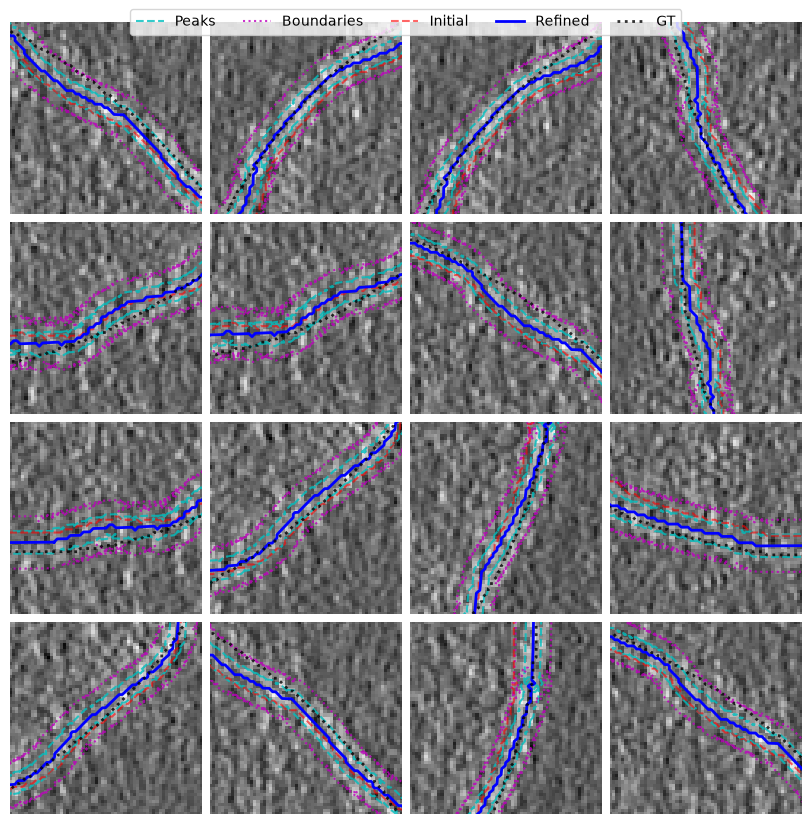

{'anchor_amp_ratio_loss': 0.0,
 'anchor_peak_dist_loss': 0.0,
 'anchor_sigma_loss': 0.0,
 'anchor_sigma_ratio_loss': 0.0,
 'contour_anchor_loss': 0.0,
 'contour_laplacian_loss': 0.0,
 'correlation_loss': 0.4744375944137573,
 'data_loss': 0.48065802454948425,
 'edge_length_loss': 0.0,
 'epoch': 0,
 'mean_dist': 1.7937426567077637,
 'normal_consistency_loss': 0.0,
 'rbf_weight_decay_loss': 0.015959840267896652,
 'shape_loss': 0.006220443639904261,
 'smooth_amp_ratio_loss': 0.0,
 'smooth_peak_dist_loss': 1.0126515626041055e-08,
 'smooth_sigma_loss': 0.0014990855706855655,
 'smooth_sigma_ratio_loss': 0.0,
 'step': 1999,
 'tangential_laplacian_loss': 0.0,
 'total_loss': 0.49811694025993347}


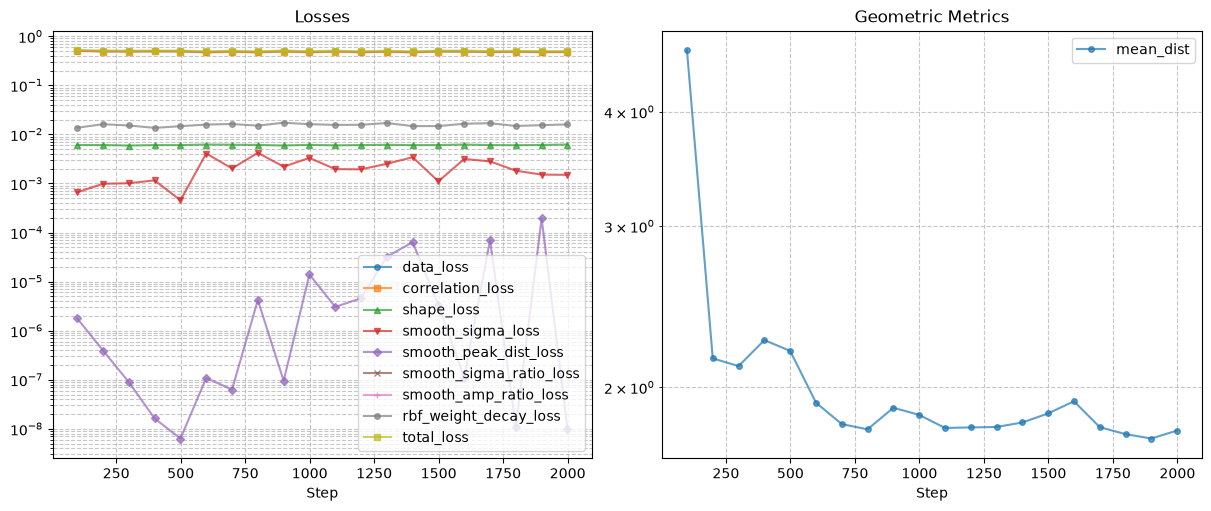

Chamfer from init 3.2795565128326416
Mean Peak Dist: 5.54, Mean Sigma1: 1.85, Mean Sigma2: 1.85
Original Peak Dist: 4.0 Original Sigma1: 0.75


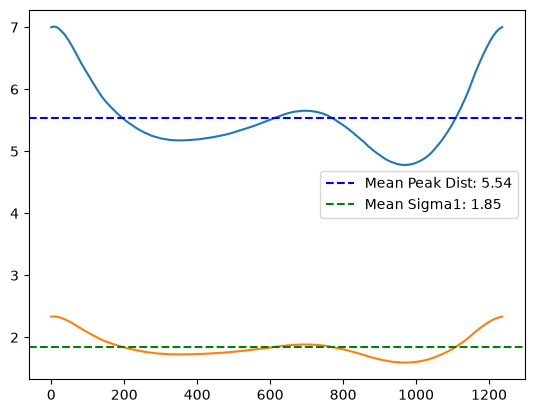

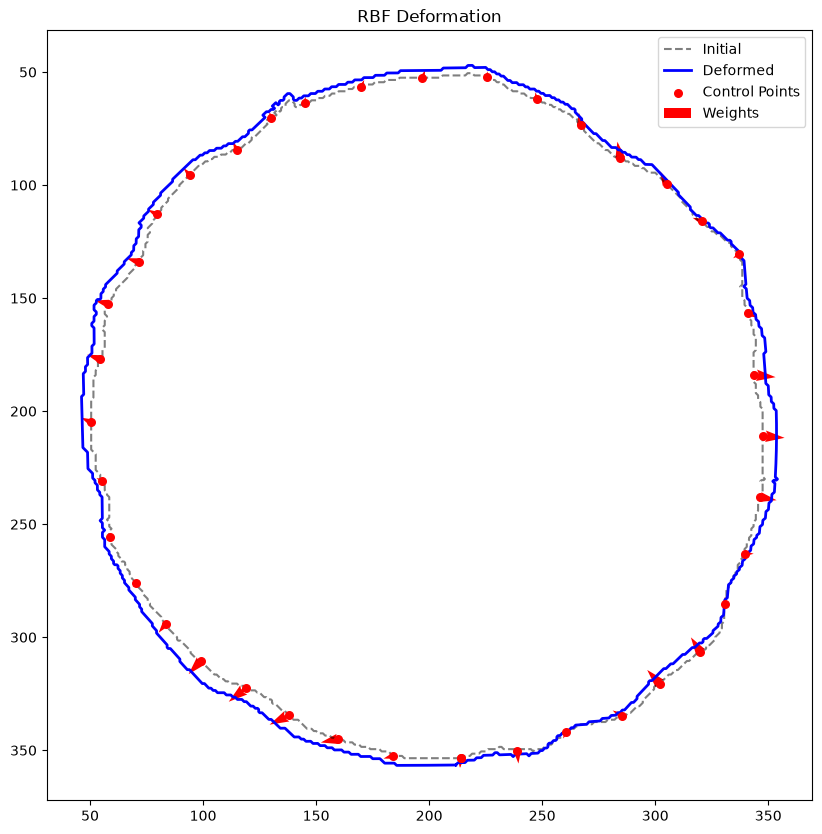

THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporarily using L2 norm for averaging template profiles for visualization.
THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporary setting for profile norm calculations. Not sure how it works with L1 vs L2.


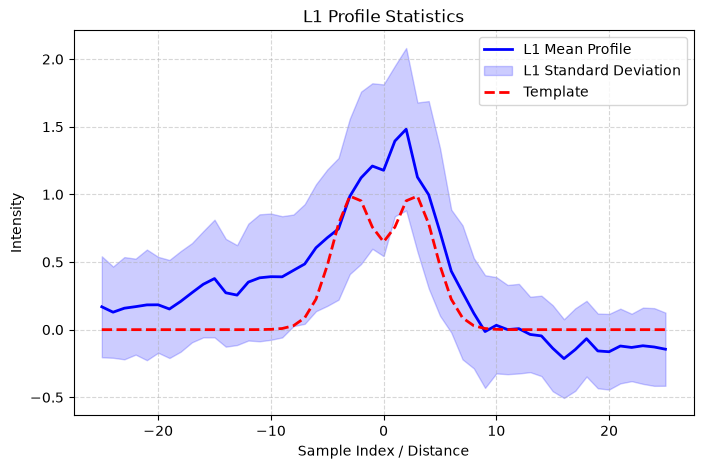

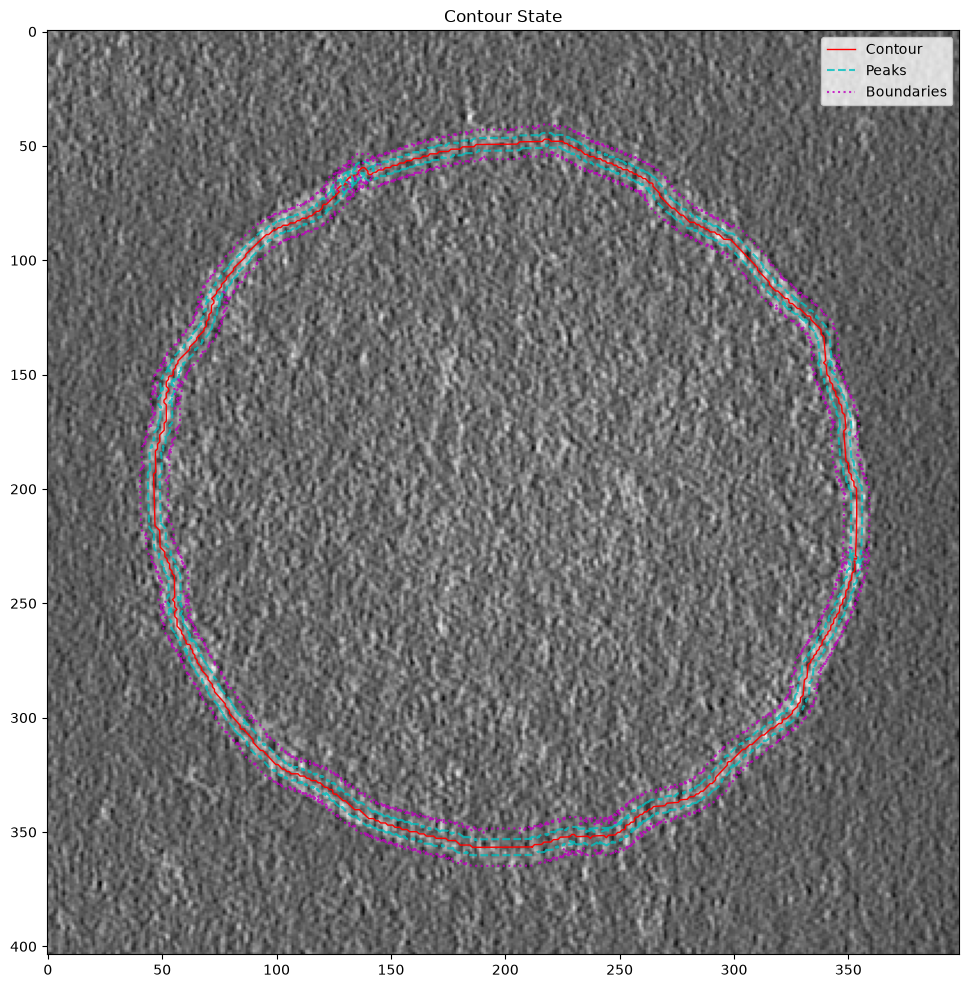

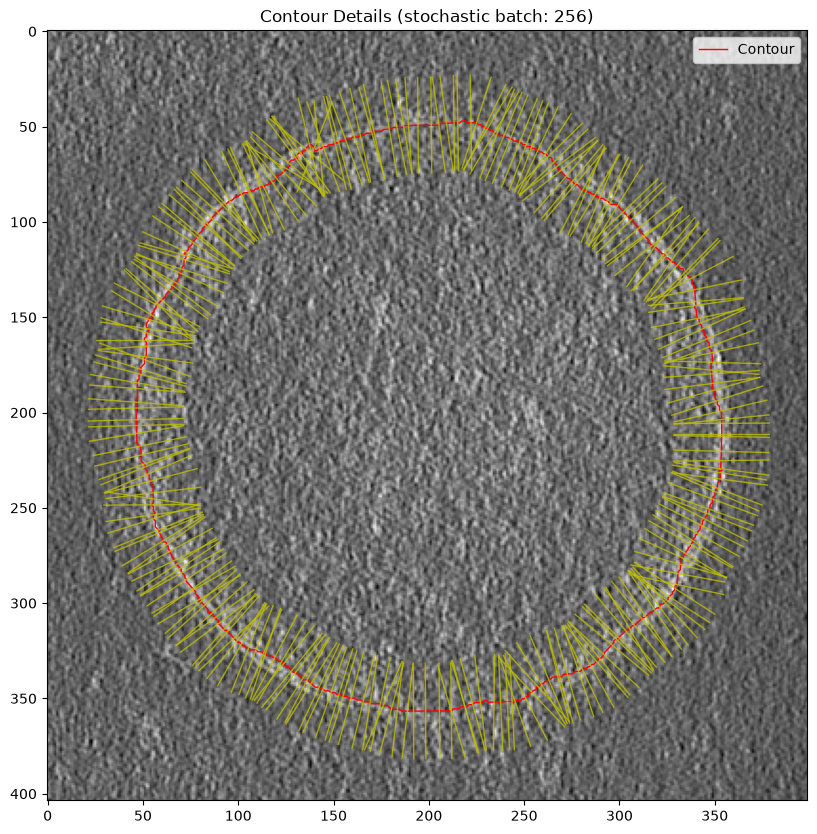

In [ ]:
generator = debug.get_generator(device=device, manual_seed=145, reset=True)
props_dict = {
    "trial_id": "verify_5A",
    "refiner": "rbf",
    "template": "bspline",
    "symmetric": True,
    "reg_mode": "static",
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 0.0,
    "w_tangential": 0,
    "w_anchor": 0.0,
    "w_smooth_param": 0.1,
    "w_contour_anchor": 0.0,
    "shape_loss_weight": 0.01,
    "learning_rate": 5e-1,
    "smoothness_window_size": 5,
    "min_peak_ratio": 3.0,
    "num_cp": 40,
    "rbf_sigma": 0.0,
}


(
    trainer,
    run_dir,
    refiner_props,
    template_props,
    t_mode,
    image,
    init_contour,
    gt_contour,
    image_t,
    contour_t,
    gt_contour_t,
) = create_trainer_with_config(props_dict=props_dict, output_subdir_name="cp_40_no_regs_2")
trainer.fit(10000)
cb = next(
    (c for c in trainer.trainer.callbacks if isinstance(c, trainer_module.ImageLoggerCallback)),
    None,
)
if cb:
    fig = cb.create_figure(trainer.model)
# trainer.plot_image()
plt.show()

pprint(trainer.trainer.logger.history[-1])
fig = trainer.plot_metrics()
display(fig)
plt.show()
# Evaluate
final_contour = trainer.refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics_from_init = hps.compute_contour_metrics(trainer.refiner.contour, contour_t)
chamfer_from_init = metrics_from_init["mean_dist"]
print("Chamfer from init", chamfer_from_init)
tmp_coords = trainer.refiner.contour
tmp_coords = tmp_coords.detach().cpu()
template_params = trainer.refiner.template_model.get_params(coordinates=tmp_coords)
(
    template_params["peak_dist"].mean(),
    template_params["peak_dist"].std(),
    template_params["sigma1"].mean(),
    template_params["sigma1"].std(),
)

mean_peak_dist = template_params["peak_dist"].detach().numpy().mean()
mean_sigma1 = template_params["sigma1"].detach().numpy().mean()
mean_sigma2 = template_params["sigma2"].detach().numpy().mean()

print(
    f"Mean Peak Dist: {mean_peak_dist:.2f}, Mean Sigma1: {mean_sigma1:.2f}, Mean Sigma2: {mean_sigma2:.2f}"
)
print(f"Original Peak Dist: {template_props.peak_dist} Original Sigma1: {template_props.sigma}")

plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())
plt.axhline(
    y=mean_peak_dist, color="b", linestyle="dashed", label=f"Mean Peak Dist: {mean_peak_dist:.2f}"
)
plt.axhline(y=mean_sigma1, color="g", linestyle="dashed", label=f"Mean Sigma1: {mean_sigma1:.2f}")
plt.legend()
plt.show()


trainer.refiner.visualize_rbf_field()
plt.show()

tmp_profiles, *_ = trainer.refiner.sample_image_features(image_t)
tmp_profiles = tmp_profiles.detach()
trainer.refiner.visualize_profile_statistics(image_t.cpu())
plt.show()
trainer.refiner.visualize_contour(image_t.detach())
vis.plot_contour_normals(image_t, tmp_coords.detach().numpy())
plt.show()

In [985]:
### Result: Seems more robust than bspline, but still not the best. The fit is too flexible and may be overfitting to noise.